## Random Forest

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [27]:
df = pd.read_csv("data/algerian_forest_fires_proj4.csv")
df.head()

,region,temp_c,rel_humidity_percent,wind_speed_kmh,rainfall_mm,ffmc,dmc,dc,isi,bui,fwi,classes
0,Bejaia,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,Bejaia,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,Bejaia,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,Bejaia,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,Bejaia,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [28]:
df.shape

(243, 12)

### Creating the Random Forest

In [29]:
tested_df = df.drop('region', axis=1).copy()
tested_df.head()

,temp_c,rel_humidity_percent,wind_speed_kmh,rainfall_mm,ffmc,dmc,dc,isi,bui,fwi,classes
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [30]:
fire_data_x = tested_df.drop('classes', axis=1)
fire_data_y = tested_df['classes']

In [31]:
cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [32]:
N_ESTIMATORS = [50, 100, 250, 500]
MAX_DEPTH = [1, 5, 10, 20]
MAX_FEAT = ['sqrt', 'log2']
CRITERION = ['gini', 'entropy']

base_rf = RandomForestClassifier(random_state=12)

parameters = {
    'n_estimators': N_ESTIMATORS,
    'max_depth': MAX_DEPTH,
    'max_features': MAX_FEAT,
    'criterion': CRITERION,
}

rf_grid = GridSearchCV(
    estimator=base_rf,
    param_grid=parameters,
    scoring='accuracy',
    cv=cross_validation,
    n_jobs=-1,
    verbose=2
)
rf_grid.fit(fire_data_x, fire_data_y)
print('Best parameters found: ', rf_grid.best_params_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV

In [33]:
BEST_RF_CLF = rf_grid.best_estimator_

In [34]:
final_scores = cross_val_score(
    BEST_RF_CLF,
    fire_data_x,
    fire_data_y,
    cv=cross_validation,
    scoring='accuracy'
)
print(final_scores)
print(final_scores.mean())
print(final_scores.std())

[0.95918367 1.         0.95918367 1.         0.97916667]
0.9795068027210885
0.01825440838330819


In [35]:
fire_predict_y = cross_val_predict(BEST_RF_CLF, fire_data_x, fire_data_y, cv=cross_validation)

In [36]:
classification_accuracy = round(accuracy_score(fire_data_y, fire_predict_y) * 100, 4)
confusion_matrix = confusion_matrix(fire_data_y, fire_predict_y)
per_class_classification = classification_report(fire_data_y, fire_predict_y)

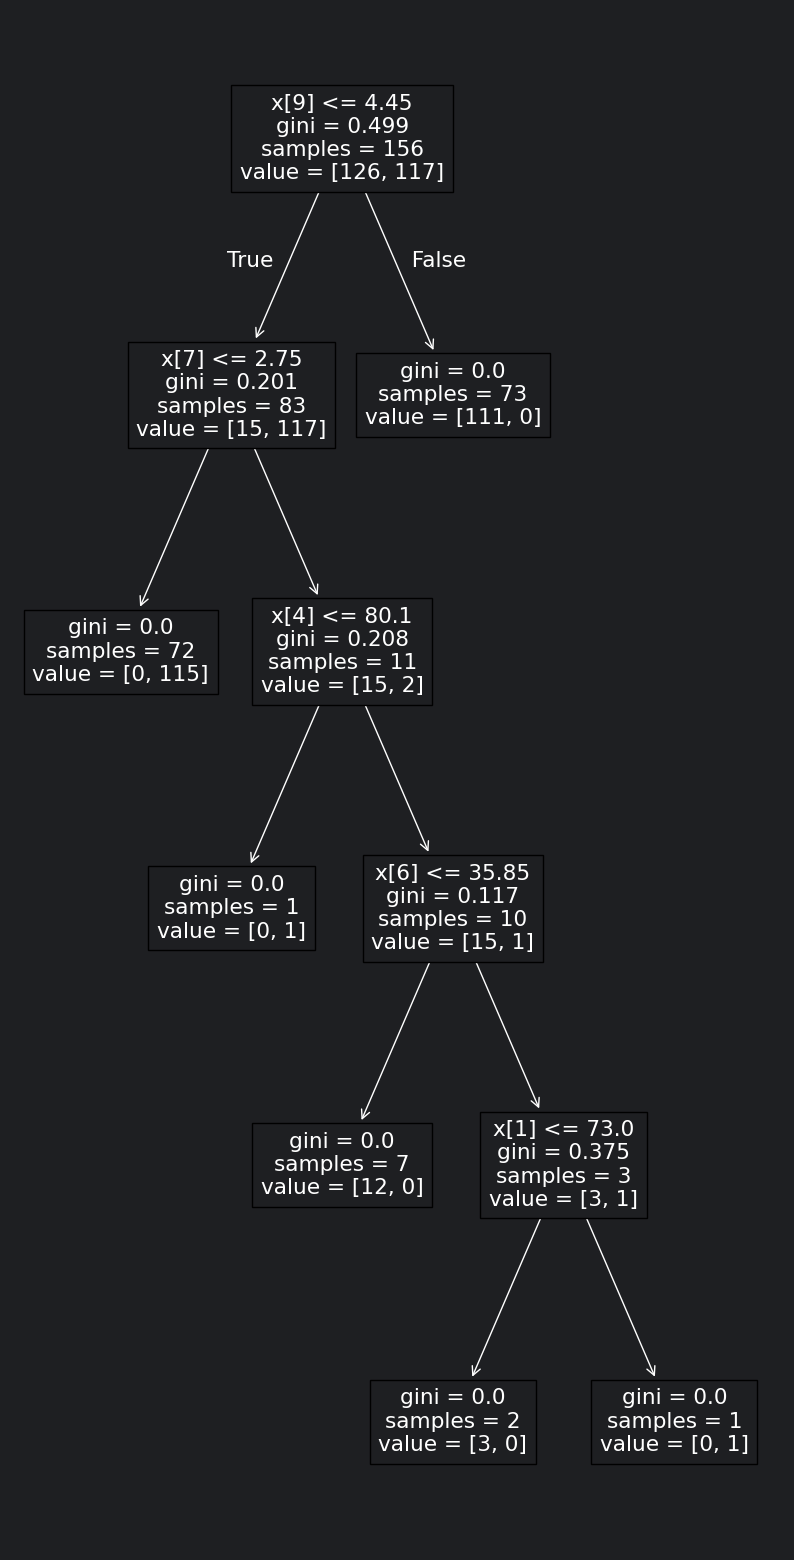

In [37]:
plt.figure(figsize=(10, 20))
tree.plot_tree(
    BEST_RF_CLF[0],
)
plt.show()

In [38]:
print(classification_accuracy)

97.9424


In [39]:
print(confusion_matrix)

[[134   3]
 [  2 104]]


In [40]:
print(per_class_classification)

              precision    recall  f1-score   support

        fire       0.99      0.98      0.98       137
    not fire       0.97      0.98      0.98       106

    accuracy                           0.98       243
   macro avg       0.98      0.98      0.98       243
weighted avg       0.98      0.98      0.98       243

